# Corpus Preparation Pipeline - Data Exploration

## 1. Setup
Set environment variables, imports and constants.

In [37]:
import dotenv
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import corpus_prep_pipeline as corpus_prep

# Reload the variables in your '.env' file (override the existing variables)
dotenv.load_dotenv(".env", override=True)

input_data_root_path = os.environ.get("INPUT_DATA_ROOT_PATH")

# Retrieve original functions without Prefect decorators
load_sequence_dataset = corpus_prep.load_sequence_dataset.__wrapped__
count_aminoacid_frequency = corpus_prep.count_aminoacid_frequency.__wrapped__

## 2. TestGroup dataset exploration

### 2.1. Sequence dataset

In [17]:

test_sequence_df = load_sequence_dataset(input_data_root_path, corpus_prep.TEST_GROUP_DATASET_NAME)
print(test_sequence_df.head(10))

   id family_name                    name  \
0   0      Globin  UniRef90_UPI00047DF566   
1   1      Globin  UniRef90_UPI00041C2C82   
2   2      Globin         UniRef90_B5FX70   
3   3      Globin         UniRef90_D3PG04   
4   4      Globin         UniRef90_C7PWU1   
5   5      Globin         UniRef90_M8E6D5   
6   6      Globin  UniRef90_UPI0006500DD2   
7   7      Globin         UniRef90_W2TL52   
8   8      Globin         UniRef90_B2IF30   
9   9      Globin     UniRef90_A0A072VP06   

                                            sequence  
0  MLSEKTIQIIKSTVPVLEKHGVEITKRFYRNMFAAHPELLNIFNHA...  
1  MLSTQSHPIIEATLPLVGEKMPEIAKNFYARLFTAHPELFDGLFSR...  
2  MVNWTAEEKQLVTTLWGRVNVDECGAEALARLLVAYPWTQRFFVSF...  
3  MVIGKKLKRHGGIVMKALGKLVGFLETGKIIAIVNTIKGIANSHSK...  
4  MDGENLNGDLLAGRAQALALVRQGFAAVSARPEVFTNSLYEDFFTS...  
5  MLSPQTIAIIKSTVPVLEVHGKAITTRFYEMMFASHPELLNIFNHA...  
6  MVHLTCEEKAFINSIWGHVNVEELGGEALGRLLVVYPWTQRFFDSF...  
7  MVSPADVKKHTVASLGVAPVGKTPEKIQNGKDFYKFFFTTHPELRK...  
8  MAEPLS

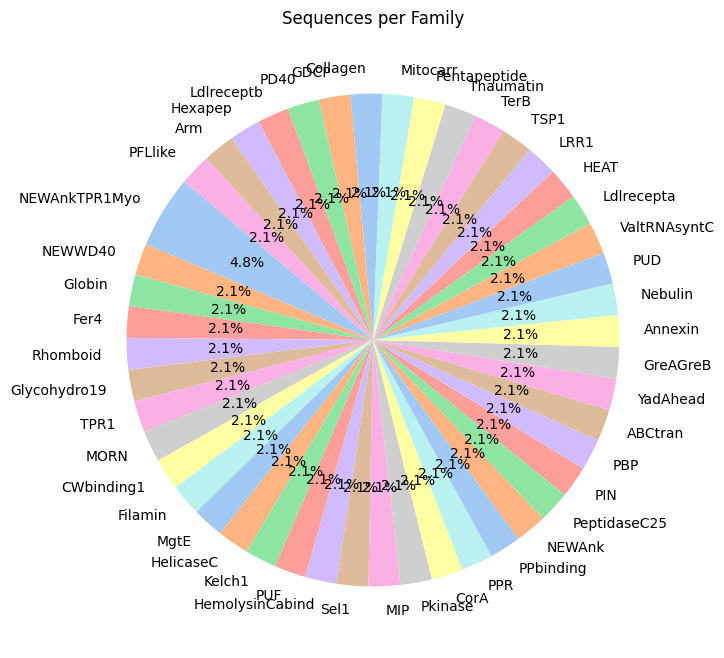

In [18]:
# 1. Explore sequence count by family

# Aggregate by family_name and count occurrences
family_sequence_counts = test_sequence_df['family_name'].value_counts().reset_index()
family_sequence_counts.columns = ['family_name', 'sequence_count']

plt.figure(figsize=(8, 8))
sns.set_palette("pastel")
plt.pie(family_sequence_counts['sequence_count'], labels=family_sequence_counts['family_name'], autopct='%1.1f%%', startangle=140)
plt.title('Sequences per Family')

# 2. Show the pie chart
plt.show()

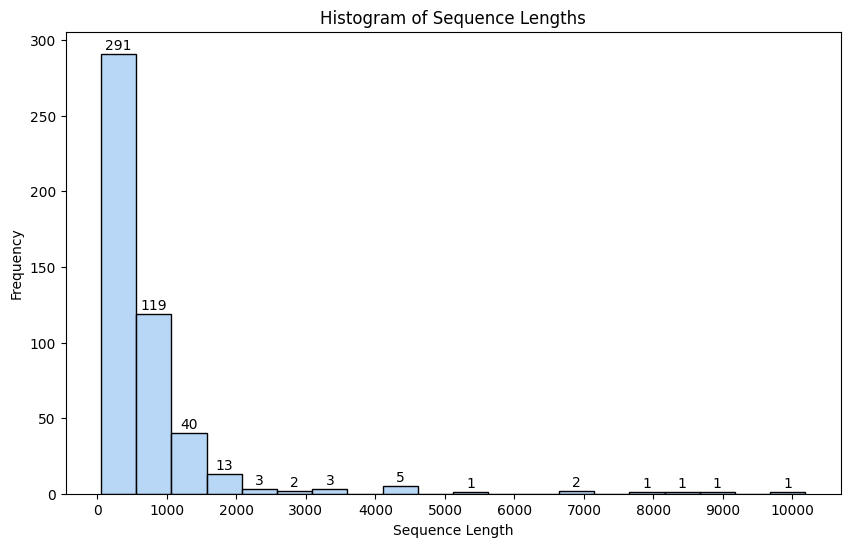

In [35]:
# 3. Explore sequence length distribution

test_sequence_df['sequence_length'] = test_sequence_df['sequence'].apply(len)

# 4. Create a histogram using Seaborn
plt.figure(figsize=(10, 6))
ts_sl_histplot = sns.histplot(test_sequence_df['sequence_length'], kde=False, bins=20)

# Add labels to each bar
for p in ts_sl_histplot.patches:
    height = p.get_height()
    if height > 0:
        ts_sl_histplot.text(p.get_x() + p.get_width() / 2., height + 3, int(height), ha="center")

# 5. Set custom x-axis ticks
plt.xticks(np.arange(0, test_sequence_df['sequence_length'].max() + 500, 1000))
plt.title('Histogram of Sequence Lengths')
plt.xlabel('Sequence Length')
plt.ylabel('Frequency')

# 5. Show the histogram
plt.show()

{'A': 0.08949698004915467, 'R': 0.05366099299302736, 'N': 0.043561110014334395, 'D': 0.060238792134108134, 'C': 0.017164078750475667, 'E': 0.05983536904629065, 'Q': 0.04035089225170167, 'G': 0.07646155034634301, 'H': 0.02246580202512668, 'I': 0.05051658183337196, 'L': 0.09398613483486834, 'K': 0.04881991593921759, 'M': 0.02004812465487298, 'F': 0.03435676906746321, 'P': 0.04907169772452211, 'S': 0.06918276782572122, 'T': 0.06009573430154874, 'W': 0.013232849511743618, 'Y': 0.030800351350036767, 'V': 0.0666535053460712, 'U': 0.0, 'O': 0.0, 'X': 0.0, 'B': 0.0, 'Z': 0.0, 'J': 0.0}


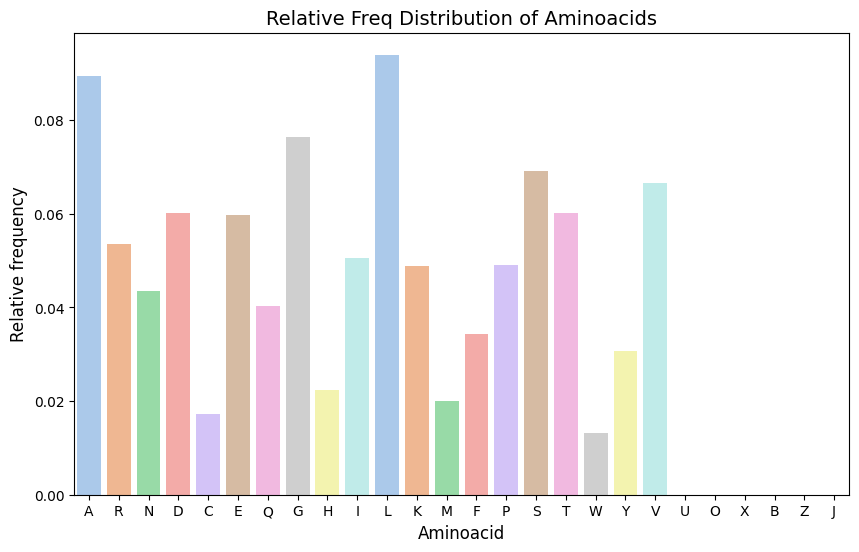

In [42]:
letter_probs = count_aminoacid_frequency(test_sequence_df)

# Extract letters and probabilities
letters = list(letter_probs.keys())
probabilities = list(letter_probs.values())

# Create the bar plot using Seaborn
plt.figure(figsize=(10, 6))
sns.barplot(x=letters, y=probabilities, hue=letters, dodge=False, palette="pastel")  # Assign 'letters' to 'hue'

# Add labels and title
plt.xlabel("Aminoacid", fontsize=12)
plt.ylabel("Relative frequency", fontsize=12)
plt.title("Relative Freq Distribution of Aminoacids", fontsize=14)
plt.legend([],[], frameon=False) # Remove legend

# Show the plot
plt.show()